In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [5]:
url = "https://air-quality-api.open-meteo.com/v1/air-quality"

params = {
    "latitude": 24.8607,
    "longitude": 67.0011,
    "hourly": "pm2_5,pm10,us_aqi",
    "start_date": "2025-10-01",
    "end_date": "2025-12-31",
    "timezone": "Asia/Karachi"
}

response = requests.get(url, params=params)
data = response.json()


In [6]:
df = pd.DataFrame({
    "timestamp": pd.to_datetime(data["hourly"]["time"]),
    "pm2_5": data["hourly"]["pm2_5"],
    "pm10": data["hourly"]["pm10"],
    "us_aqi": data["hourly"]["us_aqi"],
})

df.head()


,timestamp,pm2_5,pm10,us_aqi
0,2025-10-01 00:00:00,26.9,27.0,89
1,2025-10-01 01:00:00,24.8,24.9,88
2,2025-10-01 02:00:00,23.1,23.2,86
3,2025-10-01 03:00:00,22.1,22.2,85
4,2025-10-01 04:00:00,21.7,21.7,84


In [7]:
df.shape


(2208, 4)

In [8]:
df.isna().sum()


timestamp    0
pm2_5        0
pm10         0
us_aqi       0
dtype: int64

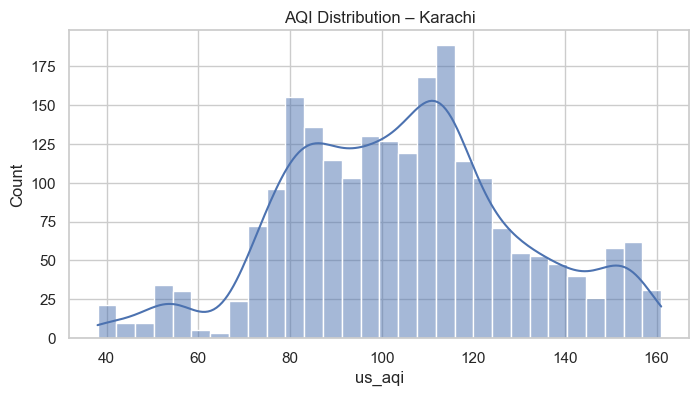

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df["us_aqi"], bins=30, kde=True)
plt.title("AQI Distribution – Karachi")
plt.show()


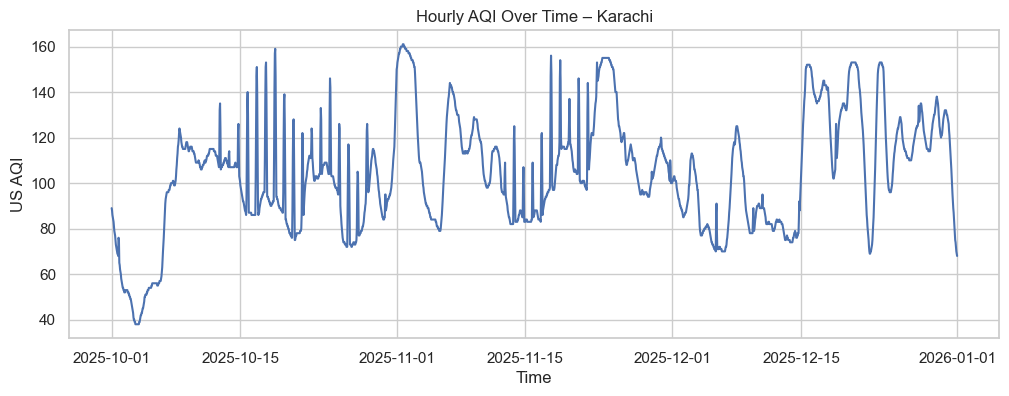

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], df["us_aqi"])
plt.title("Hourly AQI Over Time – Karachi")
plt.xlabel("Time")
plt.ylabel("US AQI")
plt.show()


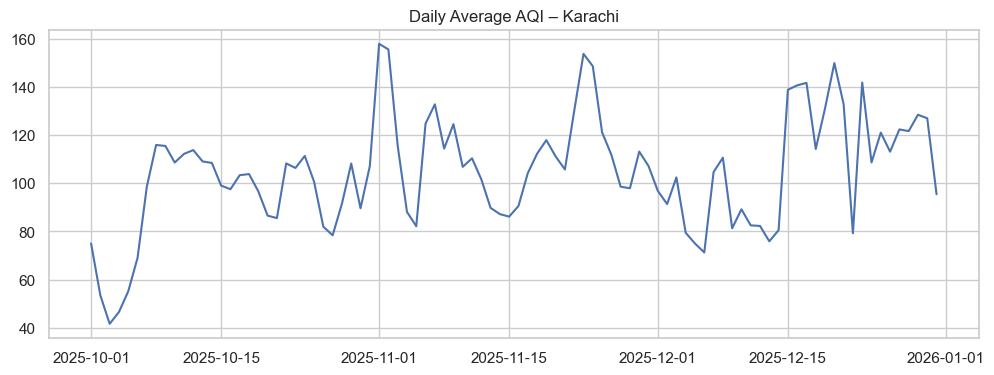

In [11]:
daily = (
    df.set_index("timestamp")
      .resample("D")
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 4))
plt.plot(daily["timestamp"], daily["us_aqi"])
plt.title("Daily Average AQI – Karachi")
plt.show()


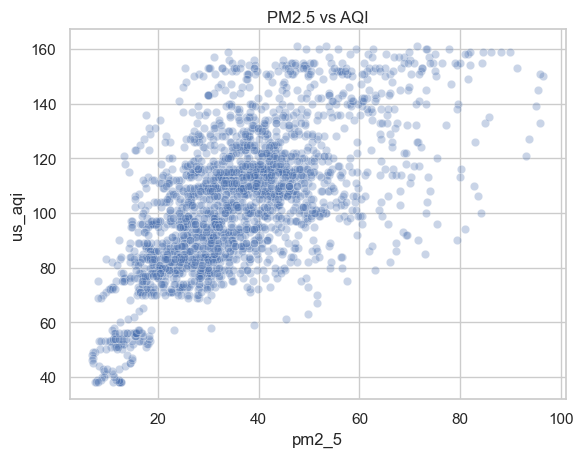

In [12]:
sns.scatterplot(data=df, x="pm2_5", y="us_aqi", alpha=0.3)
plt.title("PM2.5 vs AQI")
plt.show()


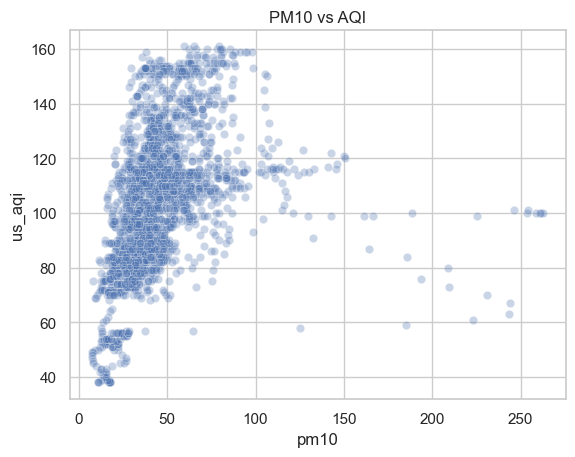

In [13]:
sns.scatterplot(data=df, x="pm10", y="us_aqi", alpha=0.3)
plt.title("PM10 vs AQI")
plt.show()


In [15]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["day_of_week"] = df["timestamp"].dt.dayofweek


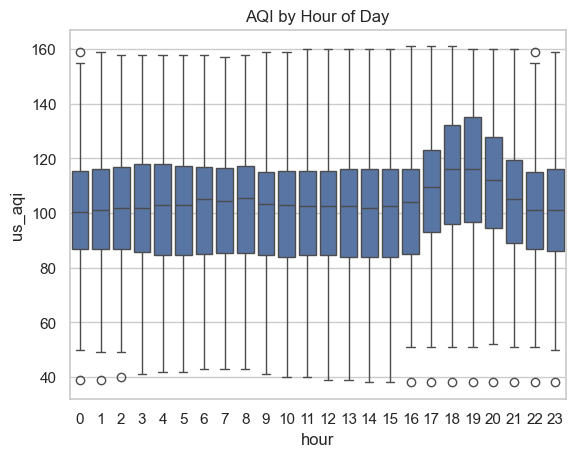

In [16]:
sns.boxplot(data=df, x="hour", y="us_aqi")
plt.title("AQI by Hour of Day")
plt.show()


In [17]:
df.to_csv("../data/raw/karachi_aqi_hourly.csv", index=False)


In [21]:
df["aqi"] = df["us_aqi"]


In [22]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["day_of_week"] = df["timestamp"].dt.dayofweek


In [23]:
lags = [1, 3, 6, 12, 24]

for lag in lags:
    df[f"aqi_lag_{lag}"] = df["aqi"].shift(lag)



In [24]:
df["aqi_change_rate"] = df["aqi"] - df["aqi"].shift(1)


In [25]:
df["rolling_24h_mean"] = df["aqi"].rolling(24).mean()


In [26]:
df.head(30)


,timestamp,pm2_5,pm10,us_aqi,hour,day,month,day_of_week,aqi,aqi_lag_1,aqi_lag_3,aqi_lag_6,aqi_lag_12,aqi_lag_24,aqi_change_rate,rolling_24h_mean
0,2025-10-01 00:00:00,26.9,27.0,89,0,1,10,2,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-10-01 01:00:00,24.8,24.9,88,1,1,10,2,88,89.0,NaN,NaN,NaN,NaN,-1.0,NaN
2,2025-10-01 02:00:00,23.1,23.2,86,2,1,10,2,86,88.0,NaN,NaN,NaN,NaN,-2.0,NaN
3,2025-10-01 03:00:00,22.1,22.2,85,3,1,10,2,85,86.0,89.0,NaN,NaN,NaN,-1.0,NaN
4,2025-10-01 04:00:00,21.7,21.7,84,4,1,10,2,84,85.0,88.0,NaN,NaN,NaN,-1.0,NaN
5,2025-10-01 05:00:00,18.8,18.9,83,5,1,10,2,83,84.0,86.0,NaN,NaN,NaN,-1.0,NaN
6,2025-10-01 06:00:00,19.3,19.4,81,6,1,10,2,81,83.0,85.0,89.0,NaN,NaN,-2.0,NaN
7,2025-10-01 07:00:00,22.2,22.4,79,7,1,10,2,79,81.0,84.0,88.0,NaN,NaN,-2.0,NaN
8,2025-10-01 08:00:00,22.2,22.3,78,8,1,10,2,78,79.0,83.0,86.0,NaN,NaN,-1.0,NaN
9,2025-10-01 09:00:00,14.8,15.0,77,9,1,10,2,77,78.0,81.0,85.0,NaN,NaN,-1.0,NaN


In [18]:
df["aqi"] = df["us_aqi"]

for lag in [1, 3, 6, 12, 24]:
    df[f"aqi_lag_{lag}"] = df["aqi"].shift(lag)

df["aqi_change_rate"] = df["aqi"] - df["aqi"].shift(1)
df["rolling_24h_mean"] = df["aqi"].rolling(24).mean()

df.head(30)


,timestamp,pm2_5,pm10,us_aqi,hour,day,month,day_of_week,aqi,aqi_lag_1,aqi_lag_3,aqi_lag_6,aqi_lag_12,aqi_lag_24,aqi_change_rate,rolling_24h_mean
0,2025-10-01 00:00:00,26.9,27.0,89,0,1,10,2,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-10-01 01:00:00,24.8,24.9,88,1,1,10,2,88,89.0,NaN,NaN,NaN,NaN,-1.0,NaN
2,2025-10-01 02:00:00,23.1,23.2,86,2,1,10,2,86,88.0,NaN,NaN,NaN,NaN,-2.0,NaN
3,2025-10-01 03:00:00,22.1,22.2,85,3,1,10,2,85,86.0,89.0,NaN,NaN,NaN,-1.0,NaN
4,2025-10-01 04:00:00,21.7,21.7,84,4,1,10,2,84,85.0,88.0,NaN,NaN,NaN,-1.0,NaN
5,2025-10-01 05:00:00,18.8,18.9,83,5,1,10,2,83,84.0,86.0,NaN,NaN,NaN,-1.0,NaN
6,2025-10-01 06:00:00,19.3,19.4,81,6,1,10,2,81,83.0,85.0,89.0,NaN,NaN,-2.0,NaN
7,2025-10-01 07:00:00,22.2,22.4,79,7,1,10,2,79,81.0,84.0,88.0,NaN,NaN,-2.0,NaN
8,2025-10-01 08:00:00,22.2,22.3,78,8,1,10,2,78,79.0,83.0,86.0,NaN,NaN,-1.0,NaN
9,2025-10-01 09:00:00,14.8,15.0,77,9,1,10,2,77,78.0,81.0,85.0,NaN,NaN,-1.0,NaN
